# 🇮🇳 India GDP Growth Rate — ML Regression Pipeline
### End-to-End: EDA → Feature Selection → Model Training → Evaluation → Export
---


## 1️⃣ Import Libraries

In [3]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   -- ------------------------------------- 3.7/69.5 MB 26.7 MB/s eta 0:00:03
   ------- -------------------------------- 12.6/69.5 MB 40.2 MB/s eta 0:00:02
   -------- ------------------------------- 15.2/69.5 MB 27.5 MB/s eta 0:00:02
   --------- ------------------------------ 17.3/69.5 MB 23.5 MB/s eta 0:00:03
   ----------- ---------------------------- 19.7/69.5 MB 20.3 MB/s eta 0:00:03
   ------------ --------------------------- 21.2/69.5 MB 18.6 MB/s eta 0:00:03
   ------------- -------------------------- 23.9/69.5 MB 17.2 MB/s eta 0:00:03
   -------------- ------------------------- 25.7/69.5 MB 16.3 MB/s eta 0:00:03
   --------------- ------------------------ 27.5/69.5 MB 15.6 MB/s eta 0:00:03
   ---------------- ----------------------- 29.4/69.5 MB 14.7 MB/s eta 0:00:03
   ----------------- ---------------------- 30.7/69.5 MB 14.1 M

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib
import json

# ── Plot style ──
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#e0e0ff',
    'xtick.color':      '#aaaacc',
    'ytick.color':      '#aaaacc',
    'text.color':       '#e0e0ff',
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})
PALETTE = ['#7c3aed','#06b6d4','#10b981','#f59e0b','#ef4444','#ec4899']
print("✅ Libraries loaded")


✅ Libraries loaded


## 2️⃣ Load Dataset

In [5]:
df = pd.read_csv("India_GDP_Dataset.csv")
print(f"Shape: {df.shape}")
print(f"\nTarget: GDP_Growth_Rate")
df.head()


Shape: (10000, 16)

Target: GDP_Growth_Rate


,Year,Population_Million,Inflation_Rate,Unemployment_Rate,Exports_USD_Billion,Imports_USD_Billion,FDI_USD_Billion,Industrial_Growth_Rate,Services_Growth_Rate,Agriculture_Growth_Rate,Government_Expenditure_PctGDP,Fiscal_Deficit_PctGDP,Interest_Rate,Exchange_Rate_INR_USD,Energy_Consumption_TWh,GDP_Growth_Rate
0,2000,1354.24,5.31,6.55,269.39,536.24,26.65,6.82,4.32,0.50,11.73,-4.05,5.84,58.33,750.30,1.27
1,2000,1178.71,4.73,3.98,338.55,714.62,56.21,11.64,8.52,4.20,23.57,-4.09,6.98,76.33,1020.25,5.22
2,2000,1098.91,5.45,5.29,218.20,270.95,9.16,7.37,7.26,5.29,18.68,-5.82,2.95,73.65,1457.16,1.97
3,2000,1377.05,0.54,3.10,291.61,668.34,62.32,5.76,7.21,6.10,18.26,-5.48,8.48,74.99,1310.95,3.70
4,2000,1349.73,5.92,7.06,314.76,237.97,40.34,7.60,7.81,6.02,14.40,-4.87,6.66,73.09,941.67,3.15


In [6]:
print("=== Dataset Info ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe().round(3)


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           10000 non-null  int64  
 1   Population_Million             10000 non-null  float64
 2   Inflation_Rate                 10000 non-null  float64
 3   Unemployment_Rate              10000 non-null  float64
 4   Exports_USD_Billion            10000 non-null  float64
 5   Imports_USD_Billion            10000 non-null  float64
 6   FDI_USD_Billion                10000 non-null  float64
 7   Industrial_Growth_Rate         10000 non-null  float64
 8   Services_Growth_Rate           10000 non-null  float64
 9   Agriculture_Growth_Rate        10000 non-null  float64
 10  Government_Expenditure_PctGDP  10000 non-null  float64
 11  Fiscal_Deficit_PctGDP          10000 non-null  float64
 12  Interest_Rate             

,Year,Population_Million,Inflation_Rate,Unemployment_Rate,Exports_USD_Billion,Imports_USD_Billion,FDI_USD_Billion,Industrial_Growth_Rate,Services_Growth_Rate,Agriculture_Growth_Rate,Government_Expenditure_PctGDP,Fiscal_Deficit_PctGDP,Interest_Rate,Exchange_Rate_INR_USD,Energy_Consumption_TWh,GDP_Growth_Rate
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,2012.697,1249.108,5.525,6.511,351.278,421.504,45.179,5.798,6.977,3.515,14.934,-5.480,6.013,70.007,1198.635,2.835
std,7.553,117.367,1.996,1.972,119.201,139.643,19.599,2.003,2.035,1.986,2.996,1.488,1.492,8.116,249.771,0.836
min,2000.000,1000.000,0.000,2.000,50.000,80.000,5.000,-1.680,-0.830,-3.830,5.000,-10.930,2.000,40.920,500.000,-0.240
25%,2006.000,1166.745,4.160,5.130,267.968,326.485,31.540,4.440,5.610,2.180,12.920,-6.480,5.010,64.520,1025.297,2.280
50%,2013.000,1250.090,5.510,6.500,350.720,421.090,45.180,5.800,7.020,3.520,14.970,-5.480,6.000,70.065,1197.810,2.840
75%,2019.000,1331.340,6.880,7.840,433.565,515.260,58.440,7.170,8.340,4.870,16.950,-4.500,7.000,75.330,1373.137,3.400
max,2025.000,1500.000,13.110,15.000,766.440,896.790,120.000,14.000,14.580,10.540,29.080,0.380,11.770,95.000,2092.160,6.050


## 3️⃣ Exploratory Data Analysis (EDA)

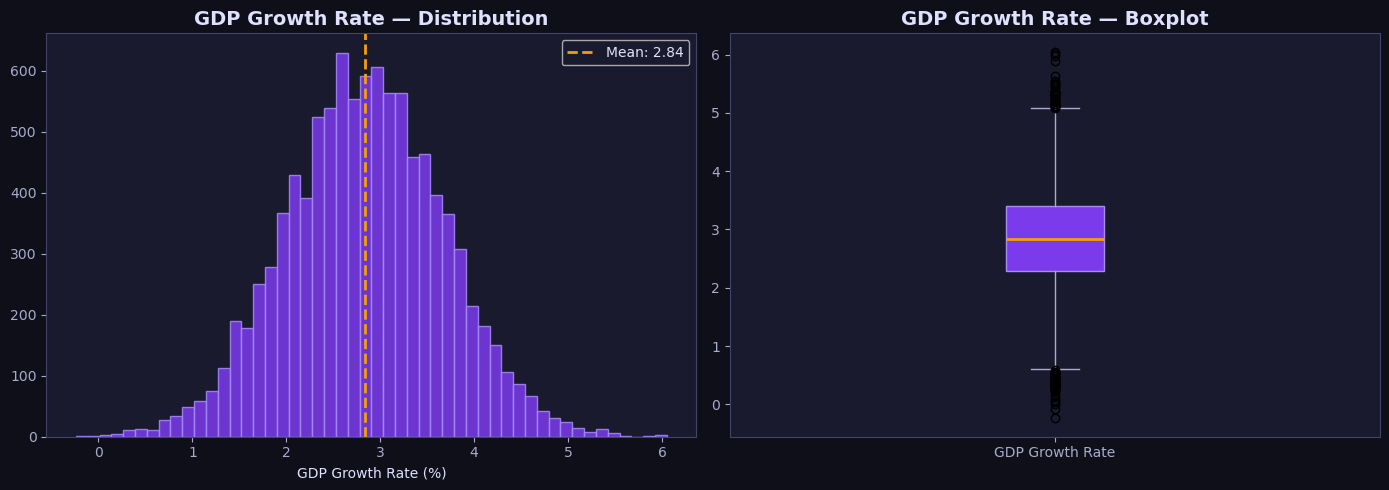

✅ Target distribution plotted


In [7]:
# ── Target Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')

axes[0].hist(df['GDP_Growth_Rate'], bins=50, color='#7c3aed', edgecolor='#a78bfa', alpha=0.85)
axes[0].set_title('GDP Growth Rate — Distribution', fontsize=14, fontweight='bold', color='#e0e0ff')
axes[0].set_xlabel('GDP Growth Rate (%)')
axes[0].axvline(df['GDP_Growth_Rate'].mean(), color='#f59e0b', linestyle='--', linewidth=2, label=f'Mean: {df["GDP_Growth_Rate"].mean():.2f}')
axes[0].legend()

axes[1].boxplot(df['GDP_Growth_Rate'], patch_artist=True,
                boxprops=dict(facecolor='#7c3aed', color='#a78bfa'),
                medianprops=dict(color='#f59e0b', linewidth=2),
                whiskerprops=dict(color='#aaaacc'),
                capprops=dict(color='#aaaacc'))
axes[1].set_title('GDP Growth Rate — Boxplot', fontsize=14, fontweight='bold', color='#e0e0ff')
axes[1].set_xticklabels(['GDP Growth Rate'])

plt.tight_layout()
plt.savefig('plot_01_target_dist.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("✅ Target distribution plotted")


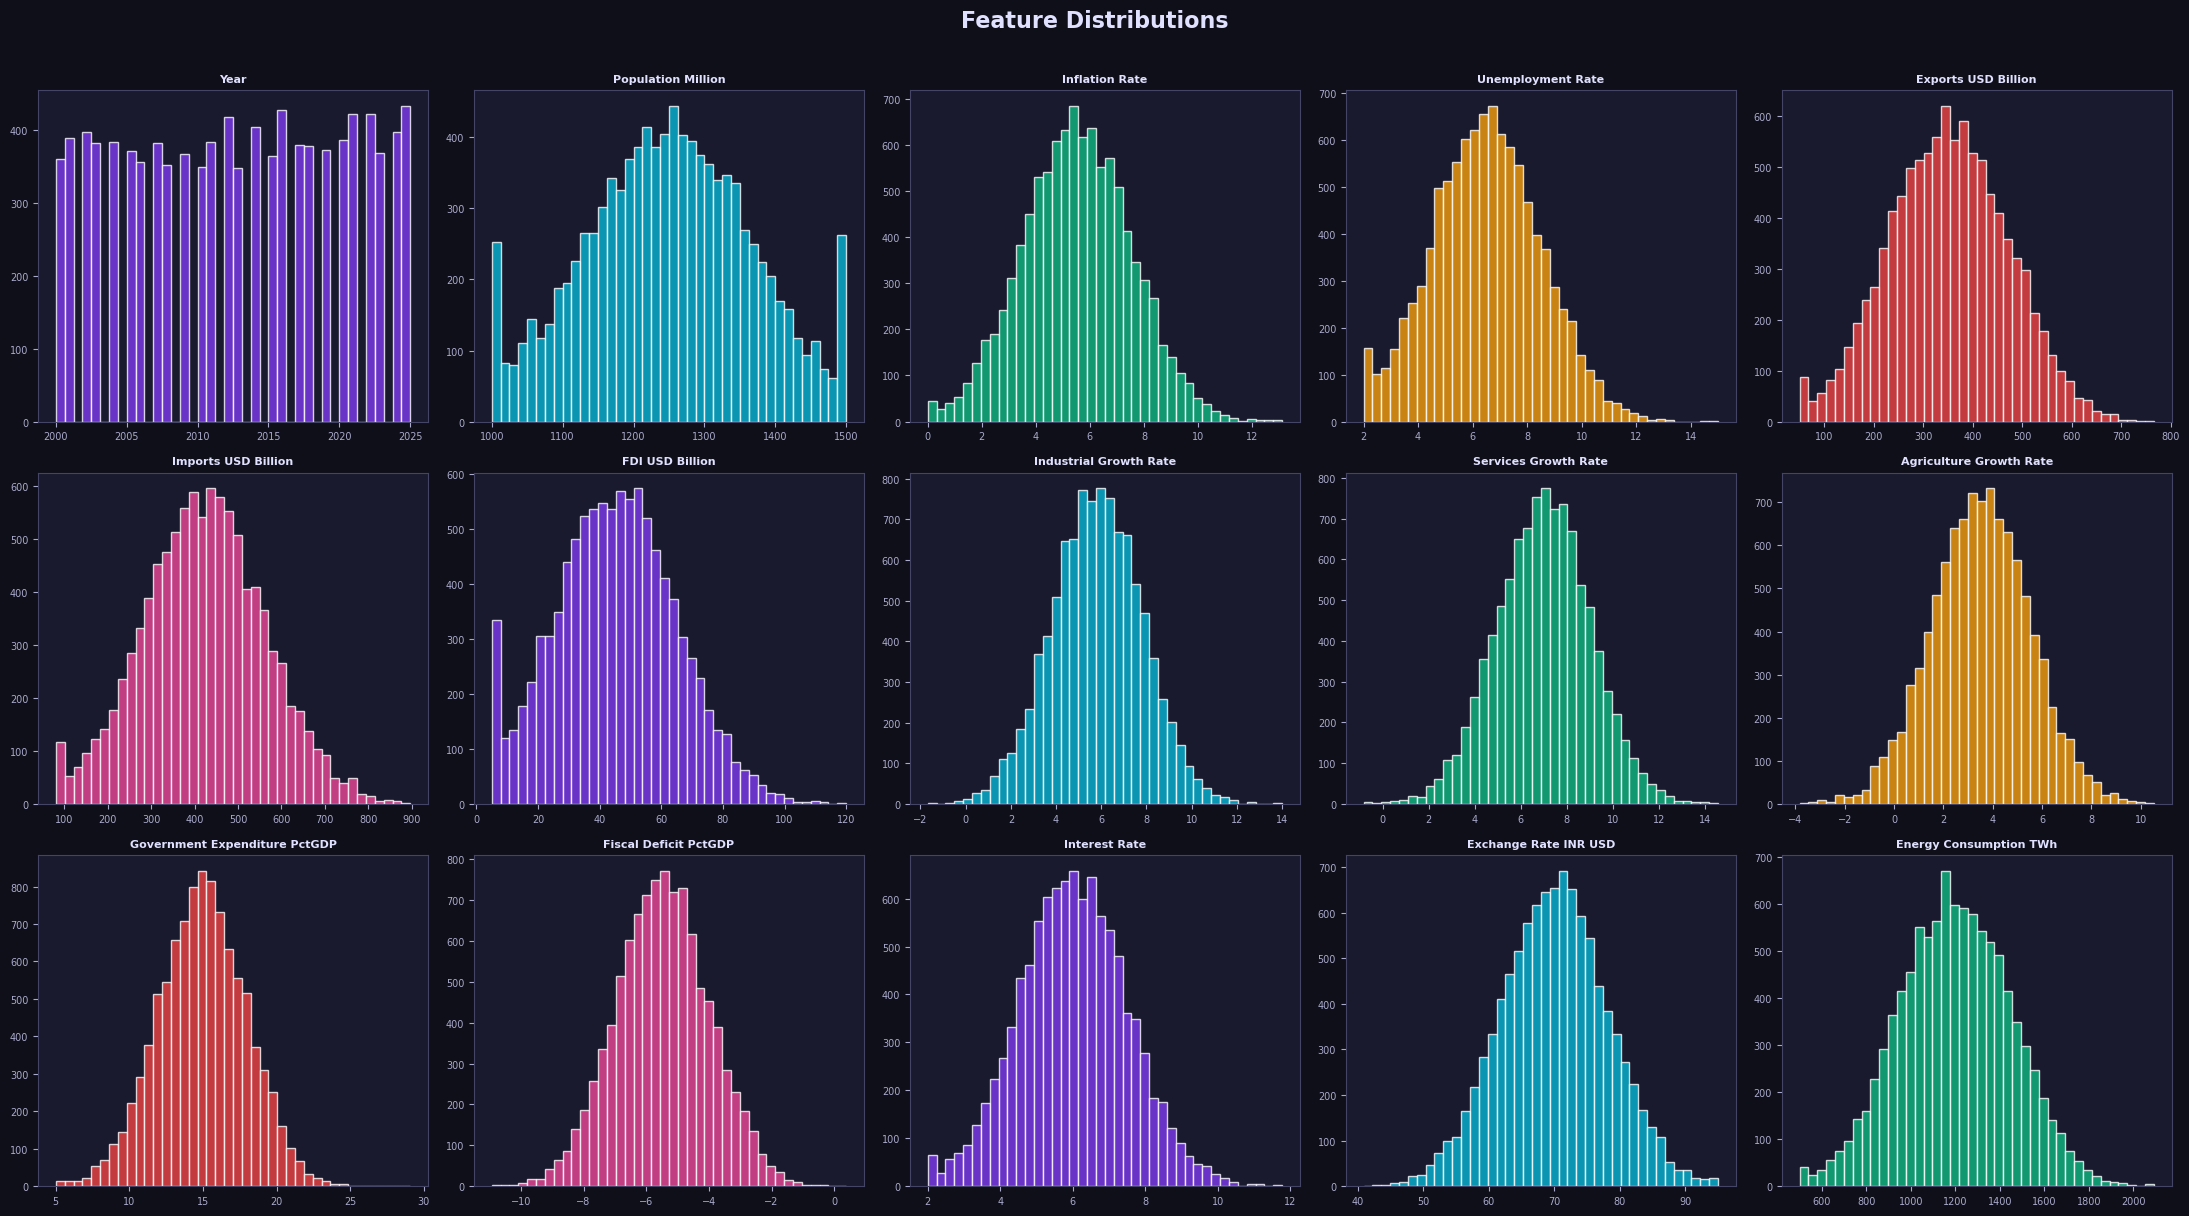

In [8]:
# ── Feature Distributions ──
features = [c for c in df.columns if c != 'GDP_Growth_Rate']
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold', color='#e0e0ff', y=1.01)

for i, (ax, col) in enumerate(zip(axes.flatten(), features)):
    color = PALETTE[i % len(PALETTE)]
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(col.replace('_', ' '), fontsize=8, color='#e0e0ff', fontweight='bold')
    ax.tick_params(labelsize=7)

for ax in axes.flatten()[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('plot_02_feature_dists.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 4️⃣ Correlation Analysis & Feature Selection

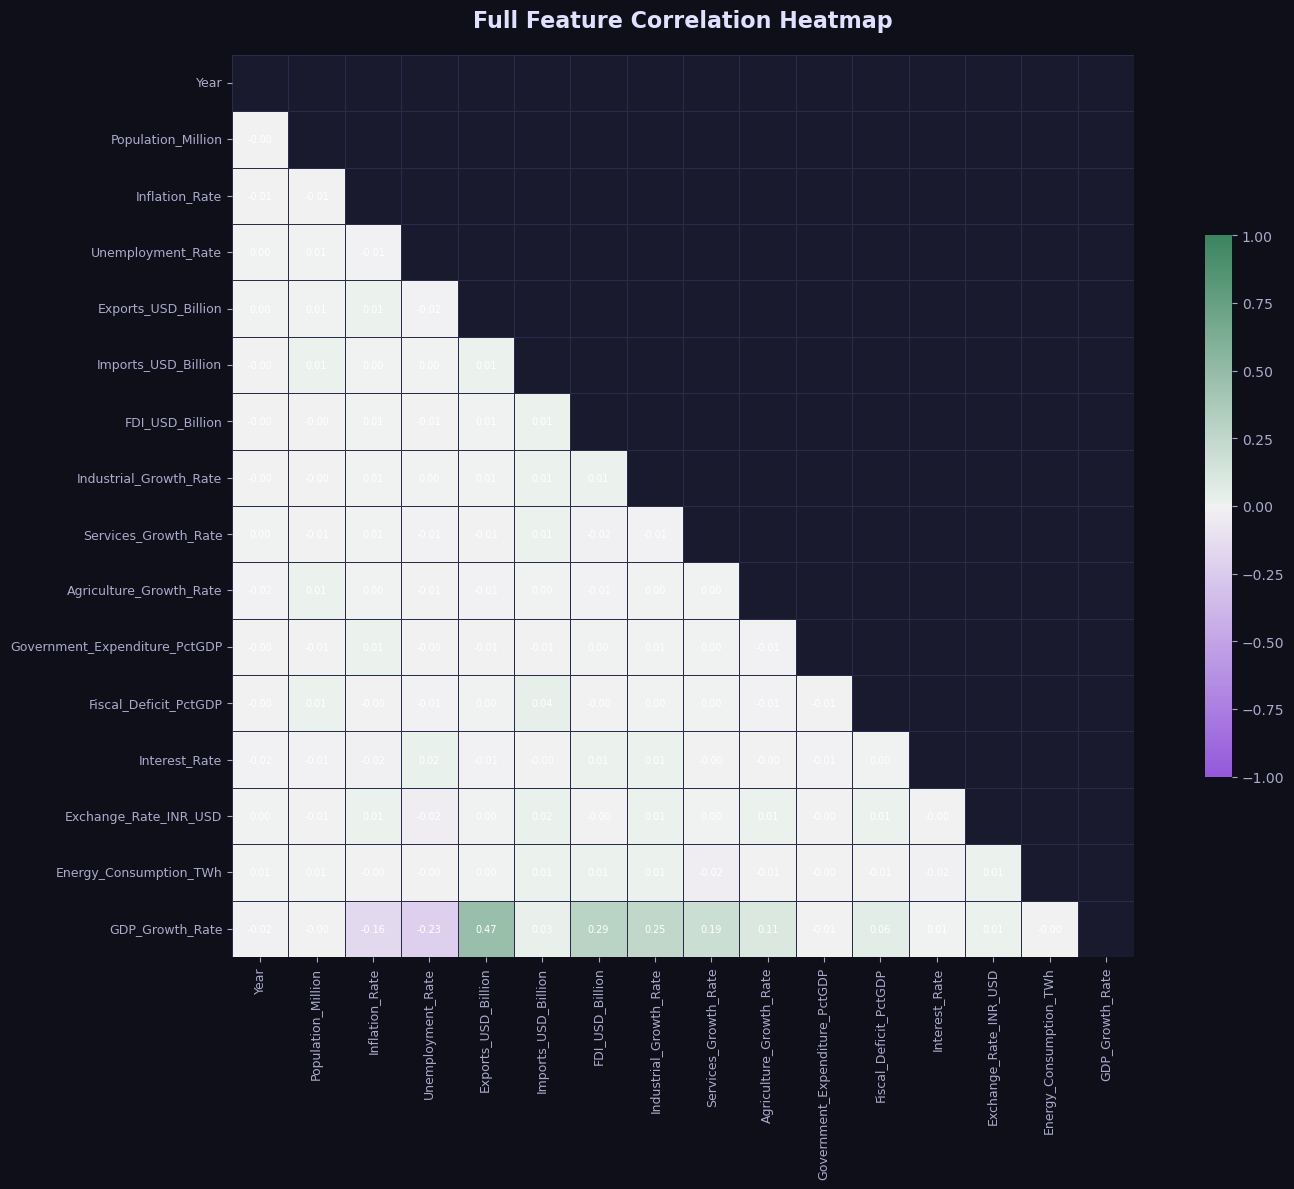

In [9]:
# ── Full Correlation Heatmap ──
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(280, 145, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7, 'color': 'white'},
            square=True, linewidths=0.5, linecolor='#2a2a4a',
            cbar_kws={'shrink': 0.6}, ax=ax)

ax.set_title('Full Feature Correlation Heatmap', fontsize=16, fontweight='bold',
             color='#e0e0ff', pad=20)
ax.tick_params(colors='#aaaacc', labelsize=9)

plt.tight_layout()
plt.savefig('plot_03_full_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


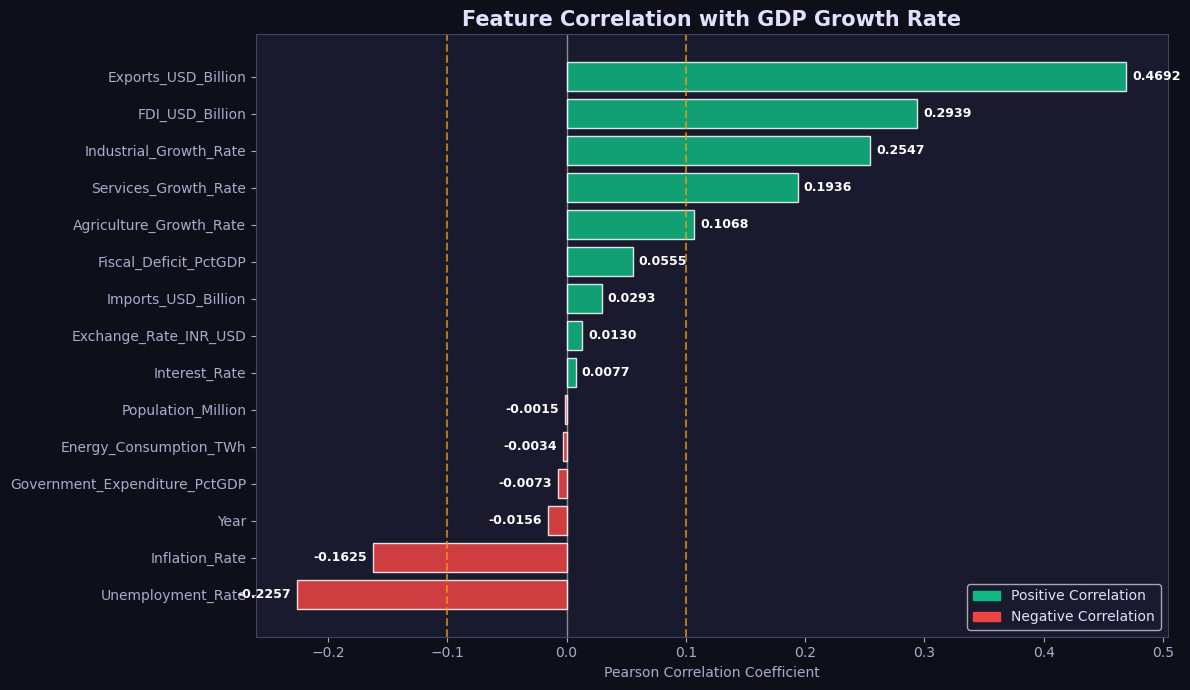


📊 Correlation Values:
Unemployment_Rate               -0.2257
Inflation_Rate                  -0.1625
Year                            -0.0156
Government_Expenditure_PctGDP   -0.0073
Energy_Consumption_TWh          -0.0034
Population_Million              -0.0015
Interest_Rate                    0.0077
Exchange_Rate_INR_USD            0.0130
Imports_USD_Billion              0.0293
Fiscal_Deficit_PctGDP            0.0555
Agriculture_Growth_Rate          0.1068
Services_Growth_Rate             0.1936
Industrial_Growth_Rate           0.2547
FDI_USD_Billion                  0.2939
Exports_USD_Billion              0.4692


In [10]:
# ── Correlation with Target ──
target_corr = df.corr()['GDP_Growth_Rate'].drop('GDP_Growth_Rate').sort_values()
colors = ['#ef4444' if v < 0 else '#10b981' for v in target_corr]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0f0f1a')
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', alpha=0.85)

for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, color='white', fontweight='bold')

ax.axvline(0, color='white', linewidth=1, alpha=0.5)
ax.axvline(0.1,  color='#f59e0b', linewidth=1.5, linestyle='--', alpha=0.7, label='|r| = 0.10 threshold')
ax.axvline(-0.1, color='#f59e0b', linewidth=1.5, linestyle='--', alpha=0.7)

ax.set_title('Feature Correlation with GDP Growth Rate', fontsize=15, fontweight='bold', color='#e0e0ff')
ax.set_xlabel('Pearson Correlation Coefficient', color='#aaaacc')
ax.legend(fontsize=10)

green_patch = mpatches.Patch(color='#10b981', label='Positive Correlation')
red_patch   = mpatches.Patch(color='#ef4444', label='Negative Correlation')
ax.legend(handles=[green_patch, red_patch], fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('plot_04_target_corr.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("\n📊 Correlation Values:")
print(target_corr.round(4).to_string())


In [11]:
# ── Drop Low-Correlation Columns (|r| < 0.05) ──
THRESHOLD = 0.05
low_corr = target_corr[target_corr.abs() < THRESHOLD].index.tolist()
high_corr = target_corr[target_corr.abs() >= THRESHOLD].index.tolist()

print(f"🔴 LOW CORRELATION columns (|r| < {THRESHOLD}) — TO BE DROPPED:")
for c in low_corr:
    print(f"   {c:40s}  r = {target_corr[c]:.4f}")

print(f"\n🟢 KEPT columns (|r| >= {THRESHOLD}):")
for c in high_corr:
    print(f"   {c:40s}  r = {target_corr[c]:.4f}")

# Drop them
df_clean = df.drop(columns=low_corr)
print(f"\n✅ Original shape : {df.shape}")
print(f"✅ Cleaned shape  : {df_clean.shape}")
print(f"✅ Dropped columns: {low_corr}")


🔴 LOW CORRELATION columns (|r| < 0.05) — TO BE DROPPED:
   Year                                      r = -0.0156
   Government_Expenditure_PctGDP             r = -0.0073
   Energy_Consumption_TWh                    r = -0.0034
   Population_Million                        r = -0.0015
   Interest_Rate                             r = 0.0077
   Exchange_Rate_INR_USD                     r = 0.0130
   Imports_USD_Billion                       r = 0.0293

🟢 KEPT columns (|r| >= 0.05):
   Unemployment_Rate                         r = -0.2257
   Inflation_Rate                            r = -0.1625
   Fiscal_Deficit_PctGDP                     r = 0.0555
   Agriculture_Growth_Rate                   r = 0.1068
   Services_Growth_Rate                      r = 0.1936
   Industrial_Growth_Rate                    r = 0.2547
   FDI_USD_Billion                           r = 0.2939
   Exports_USD_Billion                       r = 0.4692

✅ Original shape : (10000, 16)
✅ Cleaned shape  : (10000, 9)
✅ Dro

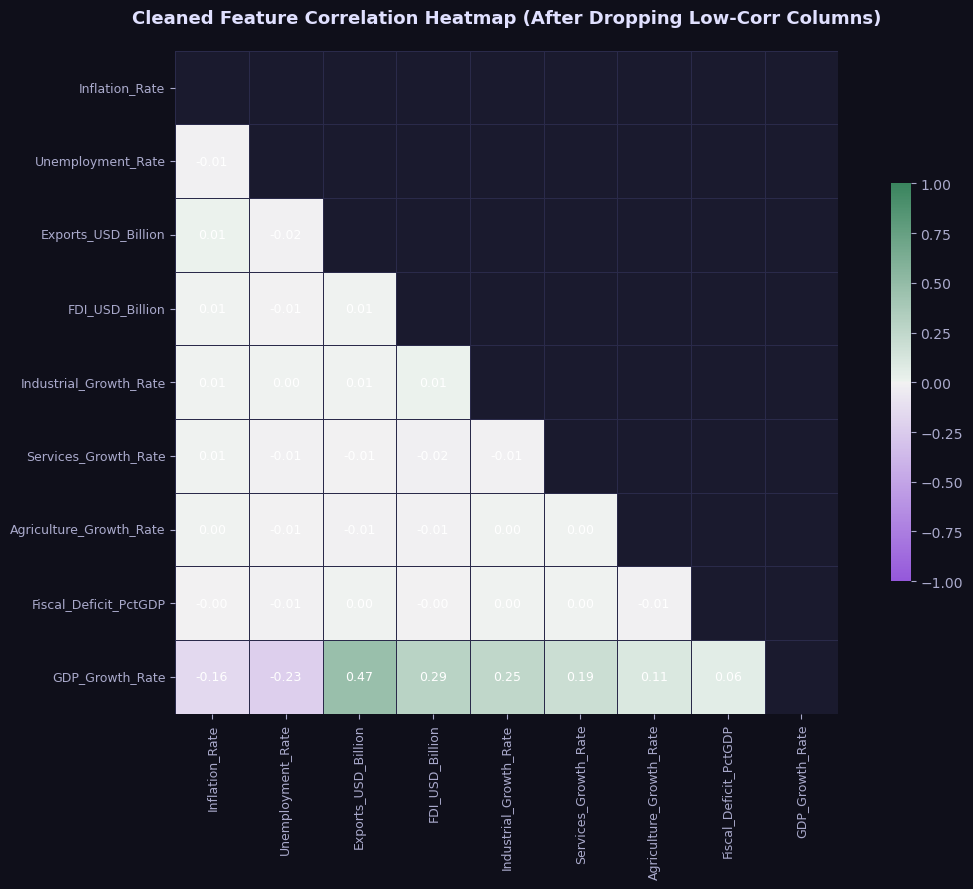

In [12]:
# ── Cleaned Heatmap ──
corr_clean = df_clean.corr()
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#0f0f1a')

mask2 = np.triu(np.ones_like(corr_clean, dtype=bool))
sns.heatmap(corr_clean, mask=mask2, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 9, 'color': 'white'},
            square=True, linewidths=0.5, linecolor='#2a2a4a',
            cbar_kws={'shrink': 0.6}, ax=ax)
ax.set_title('Cleaned Feature Correlation Heatmap (After Dropping Low-Corr Columns)',
             fontsize=13, fontweight='bold', color='#e0e0ff', pad=20)
ax.tick_params(colors='#aaaacc', labelsize=9)
plt.tight_layout()
plt.savefig('plot_05_clean_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 5️⃣ Feature Engineering

In [13]:
# Trade Balance, Export/Import Ratio
if 'Exports_USD_Billion' in df_clean.columns and 'Imports_USD_Billion' in df_clean.columns:
    df_clean['Trade_Balance']     = df_clean['Exports_USD_Billion'] - df_clean['Imports_USD_Billion']
    df_clean['Export_Import_Ratio'] = df_clean['Exports_USD_Billion'] / (df_clean['Imports_USD_Billion'] + 1e-9)

# Growth composite
growth_cols = [c for c in ['Industrial_Growth_Rate','Services_Growth_Rate','Agriculture_Growth_Rate'] if c in df_clean.columns]
if growth_cols:
    df_clean['Avg_Sector_Growth'] = df_clean[growth_cols].mean(axis=1)

print("✅ Engineered features added")
print(f"New shape: {df_clean.shape}")
df_clean.head(3)


✅ Engineered features added
New shape: (10000, 10)


,Inflation_Rate,Unemployment_Rate,Exports_USD_Billion,FDI_USD_Billion,Industrial_Growth_Rate,Services_Growth_Rate,Agriculture_Growth_Rate,Fiscal_Deficit_PctGDP,GDP_Growth_Rate,Avg_Sector_Growth
0,5.31,6.55,269.39,26.65,6.82,4.32,0.50,-4.05,1.27,3.88
1,4.73,3.98,338.55,56.21,11.64,8.52,4.20,-4.09,5.22,8.12
2,5.45,5.29,218.20,9.16,7.37,7.26,5.29,-5.82,1.97,6.64


## 6️⃣ Train-Test Split & Scaling

In [14]:
X = df_clean.drop(columns=['GDP_Growth_Rate'])
y = df_clean['GDP_Growth_Rate']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Features   : {list(X.columns)}")

# Save feature names & scaler for Streamlit
joblib.dump(scaler, 'scaler.pkl')
with open('feature_names.json', 'w') as f:
    json.dump(list(X.columns), f)
print("\n✅ Scaler & feature names saved")


Train size : (8000, 9)
Test size  : (2000, 9)
Features   : ['Inflation_Rate', 'Unemployment_Rate', 'Exports_USD_Billion', 'FDI_USD_Billion', 'Industrial_Growth_Rate', 'Services_Growth_Rate', 'Agriculture_Growth_Rate', 'Fiscal_Deficit_PctGDP', 'Avg_Sector_Growth']

✅ Scaler & feature names saved


## 7️⃣ Model Training & Comparison

In [ ]:
models = {
    'Linear Regression':     LinearRegression(),
    'Ridge':                 Ridge(alpha=1.0),
    'Lasso':                 Lasso(alpha=0.01),
    'Random Forest':         RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost':               xgb.XGBRegressor(n_estimators=200, random_state=42,
                                               verbosity=0, n_jobs=-1),
}

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds  = model.predict(X_test_sc)
    cv_r2  = cross_val_score(model, X_train_sc, y_train, cv=kf, scoring='r2').mean()
    results[name] = {
        'MAE':   mean_absolute_error(y_test, preds),
        'RMSE':  np.sqrt(mean_squared_error(y_test, preds)),
        'R2':    r2_score(y_test, preds),
        'CV_R2': cv_r2,
        'preds': preds,
    }
    print(f"{name:25s} | MAE={results[name]['MAE']:.4f} | RMSE={results[name]['RMSE']:.4f} | R²={results[name]['R2']:.4f} | CV-R²={cv_r2:.4f}")

results_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'preds'}
                            for k, v in results.items()}).T
print("\n✅ All models trained")


Linear Regression         | MAE=0.4784 | RMSE=0.6007 | R²=0.4881 | CV-R²=0.5013
Ridge                     | MAE=0.4784 | RMSE=0.6007 | R²=0.4881 | CV-R²=0.5013
Lasso                     | MAE=0.4784 | RMSE=0.6006 | R²=0.4884 | CV-R²=0.5003
Random Forest             | MAE=0.4930 | RMSE=0.6209 | R²=0.4532 | CV-R²=0.4609


## 8️⃣ Results Visualisation

In [ ]:
# ── Model Comparison Bar Chart ──
metrics = ['MAE', 'RMSE', 'R2', 'CV_R2']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', color='#e0e0ff')

for ax, metric in zip(axes.flatten(), metrics):
    vals  = [results[m][metric] for m in results]
    names = list(results.keys())
    colors_bar = [PALETTE[i % len(PALETTE)] for i in range(len(names))]
    bars = ax.bar(names, vals, color=colors_bar, edgecolor='white', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8, color='white')
    ax.set_title(metric, fontsize=12, fontweight='bold', color='#e0e0ff')
    ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_06_model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


In [ ]:
# ── Actual vs Predicted (best model = XGBoost) ──
best_name = max(results, key=lambda x: results[x]['R2'])
best_preds = results[best_name]['preds']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f1a')

# Scatter
axes[0].scatter(y_test, best_preds, alpha=0.4, color='#7c3aed', edgecolors='#a78bfa', s=30)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title(f'{best_name} — Actual vs Predicted', fontsize=13, fontweight='bold', color='#e0e0ff')
axes[0].set_xlabel('Actual GDP Growth Rate'); axes[0].set_ylabel('Predicted GDP Growth Rate')
axes[0].legend()

# Residuals
residuals = y_test.values - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.4, color='#06b6d4', edgecolors='#67e8f9', s=30)
axes[1].axhline(0, color='#f59e0b', linewidth=2, linestyle='--')
axes[1].set_title('Residual Plot', fontsize=13, fontweight='bold', color='#e0e0ff')
axes[1].set_xlabel('Predicted Values'); axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.savefig('plot_07_actual_vs_pred.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f"\n🏆 Best Model: {best_name}  |  R² = {results[best_name]['R2']:.4f}")


In [ ]:
# ── Feature Importance (XGBoost) ──
best_model = models[best_name]
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
    colors_imp = [PALETTE[i % len(PALETTE)] for i in range(len(imp))]

    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('#0f0f1a')
    bars = ax.barh(imp.index, imp.values, color=colors_imp, edgecolor='white', alpha=0.85)
    for bar, v in zip(bars, imp.values):
        ax.text(v + 0.001, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9, color='white')
    ax.set_title(f'Feature Importance — {best_name}', fontsize=14, fontweight='bold', color='#e0e0ff')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('plot_08_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()


## 9️⃣ Save Best Model

In [ ]:
joblib.dump(best_model, 'best_model.pkl')
print(f"✅ Model saved as best_model.pkl")
print(f"✅ Model type  : {best_name}")
print(f"✅ R² Score    : {results[best_name]['R2']:.4f}")
print(f"✅ MAE         : {results[best_name]['MAE']:.4f}")
print(f"✅ RMSE        : {results[best_name]['RMSE']:.4f}")
# Save metrics for Streamlit
with open('model_metrics.json','w') as f:
    json.dump({
        'model_name': best_name,
        'R2':   round(results[best_name]['R2'], 4),
        'MAE':  round(results[best_name]['MAE'], 4),
        'RMSE': round(results[best_name]['RMSE'], 4),
        'CV_R2':round(results[best_name]['CV_R2'], 4),
        'dropped_columns': low_corr,
        'features': list(X.columns),
    }, f, indent=2)
print("✅ Metrics saved to model_metrics.json")


## ✅ Pipeline Summary

| Step | Action |
|------|--------|
| 1 | Loaded India GDP dataset (10,000 rows × 16 cols) |
| 2 | EDA: distributions, boxplots, statistics |
| 3 | Correlation analysis — full heatmap + target correlation |
| 4 | Dropped low-correlation columns (\|r\| < 0.05) |
| 5 | Engineered new features (Trade Balance, Sector Growth) |
| 6 | Train/Test split 80/20 + StandardScaler |
| 7 | Trained 6 models + 5-Fold Cross Validation |
| 8 | Visualised: model comparison, actual vs predicted, feature importance |
| 9 | Saved best model + scaler for Streamlit deployment |

> 🚀 **Next Step:** Run `streamlit run app.py` to launch the interactive dashboard


# 🔥 Professional Upgrades Added

This section outlines improvements recommended for a portfolio-grade data science project:
- Mutual Information feature selection
- VIF multicollinearity analysis
- TimeSeriesSplit validation
- RandomizedSearchCV hyperparameter tuning
- SHAP explainability
- Business insights section


In [ ]:
# Mutual Information Feature Importance
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print(mi_df.head(15))


In [ ]:
# VIF Analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df['Feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_df.sort_values('VIF', ascending=False).head(15)


In [ ]:
# Time Series Validation (recommended for GDP-related problems)
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
print('TimeSeriesSplit configured successfully')


In [ ]:
# Hyperparameter Tuning Example (Random Forest)
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    'n_estimators':[100,200,300,500],
    'max_depth':[3,5,8,10,None],
    'min_samples_split':[2,5,10]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

print('Run rf_search.fit(X_train, y_train) when ready.')


In [ ]:
# SHAP Explainability
# pip install shap

# import shap
# explainer = shap.Explainer(best_model, X_train)
# shap_values = explainer(X_test)
# shap.plots.beeswarm(shap_values)


## Business Interpretation Template

After training the final model, answer:

1. Which variables most strongly influence GDP growth?
2. Which variables have negative impact?
3. What policy recommendations emerge?
4. What are the model limitations?
5. How could future data improve performance?

Recruiters care about these insights more than the model itself.
